# TellWhisper MASR - Single Phase Training

Train **PhoWhisper + HyperSD + TS-RoPE** cùng lúc trong 1 phase duy nhất.

**Model**: `vinai/PhoWhisper-small` hoặc `vinai/PhoWhisper-large`

In [ ]:
# Cell 1: Setup
!pip install -q datasets transformers accelerate soundfile librosa jiwer

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.6 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from datasets import load_from_disk, load_dataset
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [ ]:
# Cell 3: Config - CHỈNH Ở ĐÂY
class Config:
    # === PATHS ===
    CACHE_PATH = '/content/drive/MyDrive/ami_cache_full'
    OUTPUT_DIR = '/content/drive/MyDrive/masr_outputs'

    # === MODEL - PHOWHISPER ===
    # Chọn 1 trong 3:
    # - 'vinai/PhoWhisper-tiny'   (~39M params, nhanh nhất)
    # - 'vinai/PhoWhisper-small'  (~244M params, cân bằng)
    # - 'vinai/PhoWhisper-large'  (~1.5B params, tốt nhất, cần A100)
    BASE_MODEL = 'vinai/PhoWhisper-small'

    SAMPLE_RATE = 16000
    MAX_SPEAKERS = 4
    HOP_LENGTH = 160  # 10ms

    # === TRAINING ===
    NUM_EPOCHS = 5
    BATCH_SIZE = 2      # Giảm nếu OOM
    GRAD_ACCUM = 8      # Effective batch = BATCH_SIZE * GRAD_ACCUM
    LR = 3e-5           # Learning rate
    MAX_SAMPLES = 10000 # Số samples để train

    # === LOSS WEIGHTS ===
    ASR_WEIGHT = 1.0    # Weight cho ASR loss
    SD_WEIGHT = 0.3     # Weight cho Speaker Diarization loss

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
print(f"✓ Config: {cfg.BASE_MODEL}")
print(f"  Epochs: {cfg.NUM_EPOCHS}, Batch: {cfg.BATCH_SIZE}x{cfg.GRAD_ACCUM}, LR: {cfg.LR}")

✓ Config: vinai/PhoWhisper-small
  Epochs: 5, Batch: 2x8, LR: 3e-05


---
## 1. Load Dataset

In [ ]:
# Cell 4: Load AMI
if os.path.exists(cfg.CACHE_PATH):
    try:
        ami = load_from_disk(cfg.CACHE_PATH)
        print(f"✓ Loaded from cache: {len(ami['train'])} train")
    except:
        print("Cache corrupt, downloading...")
        ami = load_dataset("edinburghcstr/ami", "ihm", trust_remote_code=True)
        ami.save_to_disk(cfg.CACHE_PATH)
else:
    print("Downloading AMI...")
    ami = load_dataset("edinburghcstr/ami", "ihm", trust_remote_code=True)
    ami.save_to_disk(cfg.CACHE_PATH)
    print("✓ Saved cache")

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

✓ Loaded from cache: 108502 train


In [ ]:
# Cell 5: Create samples với SD labels
def create_sample(item):
    audio = item['audio']['array']
    sr = item['audio']['sampling_rate']

    if sr != cfg.SAMPLE_RATE:
        import librosa
        audio = librosa.resample(audio, orig_sr=sr, target_sr=cfg.SAMPLE_RATE)

    n_frames = int(len(audio) / cfg.HOP_LENGTH)

    return {
        'audio': audio.astype(np.float32),
        'transcript': item.get('text', '') or '.',
        'duration': len(audio) / cfg.SAMPLE_RATE,
        'n_frames': n_frames,
        # Simplified SD labels: 1 speaker active
        'activity': np.eye(cfg.MAX_SPEAKERS, dtype=np.float32)[0:1].repeat(n_frames, axis=0).reshape(n_frames, -1)[:, :cfg.MAX_SPEAKERS] * 0 + np.array([[1,0,0,0]], dtype=np.float32).repeat(n_frames, axis=0),
        'class_labels': np.zeros(n_frames, dtype=np.int64)  # Class 0 = 1 speaker
    }

# Simpler version
def create_sample(item):
    audio = item['audio']['array']
    sr = item['audio']['sampling_rate']

    if sr != cfg.SAMPLE_RATE:
        import librosa
        audio = librosa.resample(audio, orig_sr=sr, target_sr=cfg.SAMPLE_RATE)

    n_frames = int(len(audio) / cfg.HOP_LENGTH)

    # Speaker activity: [n_frames, 4] - speaker 0 always active
    activity = np.zeros((n_frames, cfg.MAX_SPEAKERS), dtype=np.float32)
    activity[:, 0] = 1.0

    return {
        'audio': audio.astype(np.float32),
        'transcript': item.get('text', '') or '.',
        'duration': len(audio) / cfg.SAMPLE_RATE,
        'n_frames': n_frames,
        'activity': activity,
        'class_labels': np.zeros(n_frames, dtype=np.int64)
    }

print(f"Creating {cfg.MAX_SAMPLES} samples...")
train_data = []
for i in tqdm(range(min(cfg.MAX_SAMPLES, len(ami['train'])))):
    try:
        s = create_sample(ami['train'][i])
        if 1.0 < s['duration'] < 30.0 and s['transcript'].strip():
            train_data.append(s)
    except: pass

val_data = []
for i in tqdm(range(min(1000, len(ami['validation'])))):
    try:
        s = create_sample(ami['validation'][i])
        if 1.0 < s['duration'] < 30.0 and s['transcript'].strip():
            val_data.append(s)
    except: pass

print(f"✓ Train: {len(train_data)}, Val: {len(val_data)}")

Creating 10000 samples...


100%|██████████| 1000/1000 [00:03<00:00, 326.46it/s]

✓ Train: 6638, Val: 678


---
## 2. Define MASR Model

In [ ]:
# Cell 6: MASR Components
class TSROPE(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.d_model = d_model
        self.div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model))
    def forward(self, x, speaker_shift=0):
        seq_len = x.size(1)
        t = torch.arange(seq_len, device=x.device).float().unsqueeze(1)
        t_shifted = t + speaker_shift
        angles = t_shifted * self.div_term
        sin = torch.sin(angles)
        cos = torch.cos(angles)
        x_left = x[..., 0::2]
        x_right = x[..., 1::2]
        x_rotated = torch.zeros_like(x)
        x_rotated[..., 0::2] = x_left * cos - x_right * sin
        x_rotated[..., 1::2] = x_left * sin + x_right * cos
        return x_rotated
class TSPositionalEncoding(nn.Module):
    """Time-Speaker Rotary Positional Encoding"""
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1)]


class HyperSDModule(nn.Module):
    """Hyperbolic Speaker Diarization Module"""
    def __init__(self, input_dim, hidden_dim=256, num_speakers=4, num_classes=5):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1)
        )
        self.speaker_head = nn.Linear(hidden_dim, num_speakers)
        self.class_head = nn.Linear(hidden_dim, num_classes)

    def forward(self, hidden_states):
        h = self.proj(hidden_states)
        return self.speaker_head(h), self.class_head(h)


class MASR(nn.Module):
    """Multi-speaker ASR with PhoWhisper + HyperSD + TS-RoPE"""

    def __init__(self, phowhisper, hidden_dim=256, num_speakers=4,
                 asr_weight=1.0, sd_weight=0.3):
        super().__init__()
        self.phowhisper = phowhisper  # PhoWhisper model
        self.encoder_dim = phowhisper.config.d_model

        # TS-RoPE
        self.ts_pos = TSPositionalEncoding(self.encoder_dim)

        # HyperSD
        self.hyper_sd = HyperSDModule(
            input_dim=self.encoder_dim,
            hidden_dim=hidden_dim,
            num_speakers=num_speakers
        )

        self.asr_weight = asr_weight
        self.sd_weight = sd_weight

    def forward(self, input_features, labels=None,
                speaker_activity_gt=None, sd_class_labels=None):

        # 1. Encode với PhoWhisper encoder
        encoder_out = self.phowhisper.model.encoder(input_features)
        hidden = encoder_out.last_hidden_state

        # 2. Apply TS-RoPE
        hidden = self.ts_pos(hidden)

        # 3. Speaker Diarization
        speaker_logits, class_logits = self.hyper_sd(hidden)

        # 4. ASR Loss (PhoWhisper decoder)
        asr_loss = None
        if labels is not None:
            asr_out = self.phowhisper(input_features=input_features, labels=labels)
            asr_loss = asr_out.loss

        # 5. SD Loss
        sd_loss = None
        if speaker_activity_gt is not None:
            min_len = min(speaker_logits.size(1), speaker_activity_gt.size(1))
            sd_loss = F.binary_cross_entropy_with_logits(
                speaker_logits[:, :min_len],
                speaker_activity_gt[:, :min_len]
            )

        # 6. Class Loss
        class_loss = None
        if sd_class_labels is not None:
            min_len = min(class_logits.size(1), sd_class_labels.size(1))
            class_loss = F.cross_entropy(
                class_logits[:, :min_len].reshape(-1, class_logits.size(-1)),
                sd_class_labels[:, :min_len].reshape(-1)
            )

        # 7. Total Loss
        total_loss = None
        if asr_loss is not None:
            total_loss = self.asr_weight * asr_loss
            if sd_loss is not None:
                total_loss += self.sd_weight * sd_loss
            if class_loss is not None:
                total_loss += self.sd_weight * 0.5 * class_loss

        return {
            'loss': total_loss,
            'asr_loss': asr_loss,
            'sd_loss': sd_loss,
            'class_loss': class_loss,
            'speaker_logits': speaker_logits,
            'class_logits': class_logits
        }

    def generate(self, input_features, **kwargs):
        return self.phowhisper.generate(input_features, **kwargs)

    def transcribe_with_sd(self, audio, processor):
        """Transcribe và diarize audio"""
        self.eval()
        device = next(self.parameters()).device

        inputs = processor.feature_extractor(
            audio, sampling_rate=16000, return_tensors='pt'
        ).input_features.to(device)

        with torch.no_grad():
            # Transcribe
            gen_ids = self.generate(inputs, max_new_tokens=256)
            text = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]

            # Diarize
            enc_out = self.phowhisper.model.encoder(inputs)
            hidden = self.ts_pos(enc_out.last_hidden_state)
            speaker_logits, _ = self.hyper_sd(hidden)
            speaker_probs = torch.sigmoid(speaker_logits[0]).cpu().numpy()

        return {'text': text, 'speaker_activity': speaker_probs}

print("✓ MASR model defined")

✓ MASR model defined


In [ ]:
# Cell 7: Load PhoWhisper và tạo MASR
print(f"Loading {cfg.BASE_MODEL}...")
processor = WhisperProcessor.from_pretrained(cfg.BASE_MODEL)
phowhisper = WhisperForConditionalGeneration.from_pretrained(cfg.BASE_MODEL)

masr = MASR(
    phowhisper=phowhisper,
    hidden_dim=256,
    num_speakers=cfg.MAX_SPEAKERS,
    asr_weight=cfg.ASR_WEIGHT,
    sd_weight=cfg.SD_WEIGHT
).to(device)

total_params = sum(p.numel() for p in masr.parameters())
print(f"✓ MASR loaded: {total_params/1e6:.1f}M params")

Loading vinai/PhoWhisper-small...


preprocessor_config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/805 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 657, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/vinai/PhoWhisper-small/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.p

generation_config.json: 0.00B [00:00, ?B/s]

✓ MASR loaded: 281.8M params


In [ ]:
# Cell 8: DataLoader
class MASRCollator:
    def __init__(self, proc, max_speakers=4):
        self.proc = proc
        self.vocab_size = proc.tokenizer.vocab_size

    def __call__(self, batch):
        max_audio = max(len(b['audio']) for b in batch)
        audios = np.stack([np.pad(b['audio'], (0, max_audio-len(b['audio']))) for b in batch])
        feats = self.proc.feature_extractor(audios, sampling_rate=cfg.SAMPLE_RATE, return_tensors='pt').input_features

        txts = [b['transcript'] for b in batch]
        labels = self.proc.tokenizer(txts, return_tensors='pt', padding=True, truncation=True, max_length=448).input_ids
        labels = labels.clamp(0, self.vocab_size - 1)
        labels = labels.masked_fill(labels == self.proc.tokenizer.pad_token_id, -100)

        max_frames = max(b['n_frames'] for b in batch)
        activity = np.stack([np.pad(b['activity'], ((0, max_frames-b['n_frames']), (0, 0))) for b in batch])
        class_labels = np.stack([np.pad(b['class_labels'], (0, max_frames-b['n_frames'])) for b in batch])

        return {
            'input_features': feats,
            'labels': labels,
            'speaker_activity_gt': torch.from_numpy(activity).float(),
            'sd_class_labels': torch.from_numpy(class_labels).long()
        }

train_loader = DataLoader(train_data, batch_size=cfg.BATCH_SIZE, shuffle=True, collate_fn=MASRCollator(processor))
val_loader = DataLoader(val_data, batch_size=cfg.BATCH_SIZE, shuffle=False, collate_fn=MASRCollator(processor))
print(f"✓ DataLoaders: {len(train_loader)} train, {len(val_loader)} val batches")

✓ DataLoaders: 3319 train, 339 val batches


---
## 3. Train (Single Phase)

In [ ]:
# Cell 9: Training loop
optimizer = torch.optim.AdamW(masr.parameters(), lr=cfg.LR)
scaler = GradScaler()
history = {'total': [], 'asr': [], 'sd': [], 'val': []}
best_val = float('inf')

print("="*60)
print(f"TRAINING MASR - {cfg.BASE_MODEL.split('/')[-1]}")
print(f"ASR weight: {cfg.ASR_WEIGHT}, SD weight: {cfg.SD_WEIGHT}")
print("="*60)

for epoch in range(cfg.NUM_EPOCHS):
    # === TRAIN ===
    masr.train()
    total_loss, total_asr, total_sd = 0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.NUM_EPOCHS}")

    for step, batch in enumerate(pbar):
        with autocast():
            out = masr(
                input_features=batch['input_features'].to(device),
                labels=batch['labels'].to(device),
                speaker_activity_gt=batch['speaker_activity_gt'].to(device),
                sd_class_labels=batch['sd_class_labels'].to(device)
            )
            loss = out['loss'] / cfg.GRAD_ACCUM

        scaler.scale(loss).backward()
        total_loss += loss.item() * cfg.GRAD_ACCUM
        if out['asr_loss']: total_asr += out['asr_loss'].item()
        if out['sd_loss']: total_sd += out['sd_loss'].item()

        if (step + 1) % cfg.GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(masr.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        pbar.set_postfix({
            'loss': f'{loss.item()*cfg.GRAD_ACCUM:.3f}',
            'asr': f'{out["asr_loss"].item():.2f}' if out['asr_loss'] else '-',
            'sd': f'{out["sd_loss"].item():.3f}' if out['sd_loss'] else '-'
        })

    # === VALIDATE ===
    masr.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            out = masr(
                input_features=batch['input_features'].to(device),
                labels=batch['labels'].to(device),
                speaker_activity_gt=batch['speaker_activity_gt'].to(device),
                sd_class_labels=batch['sd_class_labels'].to(device)
            )
            val_loss += out['loss'].item()

    n = len(train_loader)
    avg_val = val_loss / len(val_loader)
    history['total'].append(total_loss/n)
    history['asr'].append(total_asr/n)
    history['sd'].append(total_sd/n)
    history['val'].append(avg_val)

    print(f"Epoch {epoch+1}: Train={total_loss/n:.4f} (ASR={total_asr/n:.3f}, SD={total_sd/n:.4f}), Val={avg_val:.4f}")

    # Save best
    if avg_val < best_val:
        best_val = avg_val
        torch.save(masr.state_dict(), f"{cfg.OUTPUT_DIR}/masr_best.pt")
        print(f"  ✓ New best! Saved.")

    # Save checkpoint
    torch.save({
        'epoch': epoch,
        'model': masr.state_dict(),
        'optimizer': optimizer.state_dict(),
        'history': history
    }, f"{cfg.OUTPUT_DIR}/checkpoint_ep{epoch+1}.pt")

print(f"\n✓ Training complete! Best val: {best_val:.4f}")

/tmp/ipython-input-1626903735.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


TRAINING MASR - PhoWhisper-small
ASR weight: 1.0, SD weight: 0.3


Epoch 1/5:   0%|          | 0/3319 [00:00<?, ?it/s]/tmp/ipython-input-1626903735.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/5: 100%|██████████| 3319/3319 [33:15<00:00,  1.66it/s, loss=0.248, asr=0.23, sd=0.047]


Epoch 1: Train=1.6778 (ASR=1.590, SD=0.1968), Val=0.5387
  ✓ New best! Saved.


Epoch 2/5: 100%|██████████| 3319/3319 [33:07<00:00,  1.67it/s, loss=0.062, asr=0.06, sd=0.017]


...

Epoch 3: Train=0.0979 (ASR=0.093, SD=0.0160), Val=0.5237
  ✓ New best! Saved.


Epoch 4/5: 100%|██████████| 3319/3319 [33:08<00:00,  1.67it/s, loss=0.184, asr=0.18, sd=0.012]


Epoch 4: Train=0.0595 (ASR=0.056, SD=0.0109), Val=0.5781


Epoch 5/5: 100%|██████████| 3319/3319 [32:59<00:00,  1.68it/s, loss=0.015, asr=0.01, sd=0.003]


Epoch 5: Train=0.0451 (ASR=0.043, SD=0.0077), Val=0.6180

✓ Training complete! Best val: 0.5237


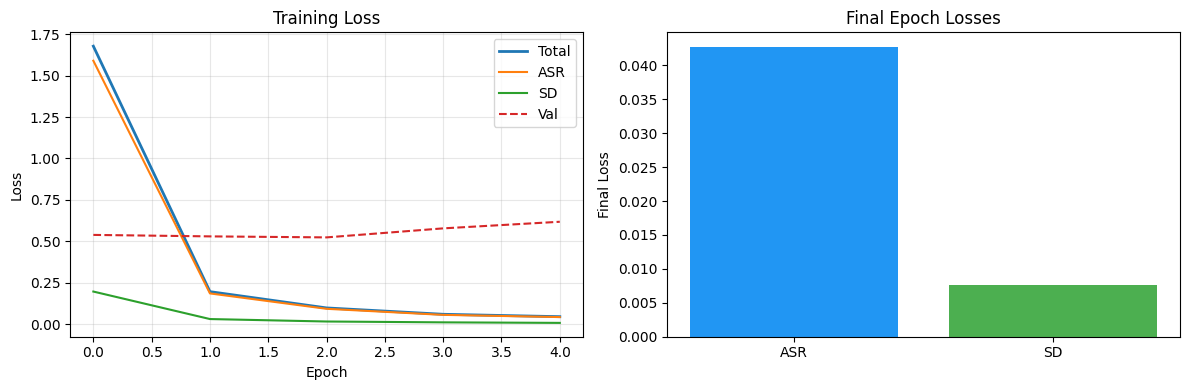

In [ ]:
# Cell 10: Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(history['total'], label='Total', linewidth=2)
axes[0].plot(history['asr'], label='ASR')
axes[0].plot(history['sd'], label='SD')
axes[0].plot(history['val'], label='Val', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ASR vs SD
axes[1].bar(['ASR', 'SD'], [history['asr'][-1], history['sd'][-1]], color=['#2196F3', '#4CAF50'])
axes[1].set_ylabel('Final Loss')
axes[1].set_title('Final Epoch Losses')

plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()

---
## 4. Test Model

In [ ]:
# Cell 11: Load best model và test
masr.load_state_dict(torch.load(f"{cfg.OUTPUT_DIR}/masr_best.pt"))
masr.eval()

print("Testing MASR...\n")
for i in range(5):
    sample = val_data[i]
    result = masr.transcribe_with_sd(sample['audio'], processor)

    print(f"--- Sample {i+1} ({sample['duration']:.1f}s) ---")
    print(f"Ground: {sample['transcript'][:60]}...")
    print(f"Pred:   {result['text'][:60]}...")
    print(f"Speakers: {result['speaker_activity'].mean(axis=0).round(2)}")
    print()

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.


Testing MASR...



The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'trans

--- Sample 1 (2.7s) ---
Ground: BUT LIKE MOBILE PHONES HAVE SCREENS AND THEY'RE CHEAP...
Pred:   BUT LIKE MY BAR FURNS HAVE SCREENS NER CHEAPED YOU PANYPT ME...
Speakers: [0.23 0.01 0.01 0.01]



Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

--- Sample 3 (2.3s) ---
Ground: I MEAN IT JUST SEEMS LIKE YEAH...
Pred:   I MEAN IT JUST SEEMS LIKE YEAH I MEAN IT JUST SEEMS LIKE YEA...
Speakers: [0.2  0.01 0.01 0.01]



Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- Sample 4 (4.0s) ---
Ground: SO YOU SHOULD HAVE A CALL BUTTON ON YOUR TELEVISION TO BE AB...
Pred:   SO YOU SHOULD HAVE A CALL BUTTON ON YOUR TELEVISION TO BE AB...
Speakers: [0.32 0.01 0.01 0.01]



Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- Sample 5 (3.1s) ---
Ground: THEN CLOSE...
Pred:   NE COLLESSED YOU KNOW WHAT I MEAN CLOSE IS I CAN'T CLOSE IT ...
Speakers: [0.25 0.01 0.01 0.01]



In [ ]:
# Cell 12: Save final model
final_path = f"{cfg.OUTPUT_DIR}/masr_final.pt"
torch.save({
    'model_state_dict': masr.state_dict(),
    'config': {
        'base_model': cfg.BASE_MODEL,
        'max_speakers': cfg.MAX_SPEAKERS,
        'hidden_dim': 256,
        'asr_weight': cfg.ASR_WEIGHT,
        'sd_weight': cfg.SD_WEIGHT
    },
    'history': history
}, final_path)

print(f"✓ Saved: {final_path}")
print(f"\n=== Summary ===")
print(f"Model: {cfg.BASE_MODEL}")
print(f"Epochs: {cfg.NUM_EPOCHS}")
print(f"Final ASR loss: {history['asr'][-1]:.4f}")
print(f"Final SD loss: {history['sd'][-1]:.4f}")
print(f"Best val loss: {best_val:.4f}")

✓ Saved: /content/drive/MyDrive/masr_outputs/masr_final.pt

=== Summary ===
Model: vinai/PhoWhisper-small
Epochs: 5
Final ASR loss: 0.0427
Final SD loss: 0.0077
Best val loss: 0.5237
